# Benchmark ODE Test Problem

This notebook compares **Euler**, **RK2**, and **RK4** on the benchmark initial value problem

\[
$\frac{dy}{dt} = -2y, \qquad y(0)=1$,
\]

with exact solution

\[
$y(t)=e^{-2t}$.
\]

The notebook generates:
- solution comparison data,
- convergence data and observed order,
- a log--log convergence plot,
- a simple timing comparison.

This version is aligned with the report appendix and is formatted to be clean enough for submission.


In [3]:
using Plots

# -------------------------
# Benchmark problem
# -------------------------
f(t, y) = -2*y
y_exact(t) = exp(-2*t)

t0 = 0.0
y0 = 1.0
T  = 2.0


2.0

## Numerical methods

In [4]:
## Euler Method Implementation
function euler(f, t0, y0, T, h)
    @assert h > 0 "Step size h must be positive."
    @assert T >= t0 "Final time T must satisfy T >= t0."

    N = Int(round((T - t0)/h))
    t = collect(range(t0, step=h, length=N+1))
    y = zeros(Float64, N+1)
    y[1] = y0

    for n in 1:N
        y[n+1] = y[n] + h*f(t[n], y[n])
    end

    return t, y
end

## RK2 Method Implementation
function rk2(f, t0, y0, T, h)
    @assert h > 0 "Step size h must be positive."
    @assert T >= t0 "Final time T must satisfy T >= t0."

    N = Int(round((T - t0)/h))
    t = collect(range(t0, step=h, length=N+1))
    y = zeros(Float64, N+1)
    y[1] = y0

    for n in 1:N
        k1 = f(t[n], y[n])
        k2 = f(t[n] + h, y[n] + h*k1)
        y[n+1] = y[n] + (h/2)*(k1 + k2)
    end

    return t, y
end

## RK4 Method Implementation
function rk4(f, t0, y0, T, h)
    @assert h > 0 "Step size h must be positive."
    @assert T >= t0 "Final time T must satisfy T >= t0."

    N = Int(round((T - t0)/h))
    t = collect(range(t0, step=h, length=N+1))
    y = zeros(Float64, N+1)
    y[1] = y0

    for n in 1:N
        k1 = f(t[n], y[n])
        k2 = f(t[n] + h/2, y[n] + (h/2)*k1)
        k3 = f(t[n] + h/2, y[n] + (h/2)*k2)
        k4 = f(t[n] + h,   y[n] + h*k3)

        y[n+1] = y[n] + (h/6)*(k1 + 2k2 + 2k3 + k4)
    end

    return t, y
end


rk4 (generic function with 1 method)

## Accuracy utilities

In [5]:
function max_error(t, y_num, y_exact)
    y_true = [y_exact(ti) for ti in t]
    return maximum(abs.(y_true .- y_num))
end

function empirical_order(Eh, Eh2)
    return log(Eh/Eh2) / log(2)
end


empirical_order (generic function with 1 method)

## Convergence data

In [6]:
hs = [0.4, 0.2, 0.1, 0.05, 0.025]

scalar_methods = Dict(
    "Euler" => euler,
    "RK2"   => rk2,
    "RK4"   => rk4
)

errors = Dict{String, Vector{Float64}}()

for (name, method) in scalar_methods
    err = Float64[]
    for h in hs
        t, y_num = method(f, t0, y0, T, h)
        push!(err, max_error(t, y_num, y_exact))
    end
    errors[name] = err
end

println("Convergence data")
println("---------------------------------------------------------------")
println("Method    h         max error           observed order")
println("---------------------------------------------------------------")

for name in ["Euler", "RK2", "RK4"]
    err = errors[name]
    for i in eachindex(hs)
        if i == 1
            println(name, "  h=", hs[i], "  error=", err[i], "  order=-")
        else
            p = empirical_order(err[i-1], err[i])
            println(name, "  h=", hs[i], "  error=", err[i], "  order=", p)
        end
    end
    println("---------------------------------------------------------------")
end

Convergence data
---------------------------------------------------------------
Method    h         max error           observed order
---------------------------------------------------------------
Euler  h=0.4  error=0.2493289641172216  order=-
Euler  h=0.2  error=0.08932896411722158  order=1.4808505506990945
Euler  h=0.1  error=0.04019944117144231  order=1.151952586095202
Euler  h=0.05  error=0.019201001071442347  order=1.0659939162002954
Euler  h=0.025  error=0.009393518762900122  order=1.0314439396218529
---------------------------------------------------------------
RK2  h=0.4  error=0.07067103588277845  order=-
RK2  h=0.2  error=0.013237788087797797  order=2.4164569746532627
RK2  h=0.1  error=0.0028604020285575293  order=2.2103722445800837
RK2  h=0.05  error=0.0006615436621095205  order=2.1123096484362334
RK2  h=0.025  error=0.00015918050041463516  order=2.0551727612179187
---------------------------------------------------------------
RK4  h=0.4  error=0.002404369216111757  or

## Plot 1: Numerical solution comparison

In [7]:
h_plot = 0.2

t_e, y_e     = euler(f, t0, y0, T, h_plot)
t_rk2, y_rk2 = rk2(f, t0, y0, T, h_plot)
t_rk4, y_rk4 = rk4(f, t0, y0, T, h_plot)

t_exact = 0:0.01:T
y_true = [y_exact(ti) for ti in t_exact]

plot(t_exact, y_true, label="Exact", linewidth=3)
plot!(t_e, y_e, marker=:circle, label="Euler")
plot!(t_rk2, y_rk2, marker=:square, label="RK2")
plot!(t_rk4, y_rk4, marker=:diamond, label="RK4")
xlabel!("t")
ylabel!("y(t)")
title!("Comparison of Euler, RK2, and RK4 for y' = -2y")

savefig("comparison_plot.png")
println("Saved comparison plot to comparison_plot.png")


Saved comparison plot to comparison_plot.png


## Plot 2: Convergence plot

In [19]:
plot(
    hs, errors["Euler"],
    xscale=:log10, yscale=:log10,
    marker=:circle, linewidth=2, label="Euler", xticks = (hs, string.(hs))
)
plot!(hs, errors["RK2"], marker=:square, linewidth=2, label="RK2")
plot!(hs, errors["RK4"], marker=:diamond, linewidth=2, label="RK4")
xlabel!("Step size h")
ylabel!("Maximum global error")
title!("Convergence of Euler, RK2, and RK4")



savefig("convergence_plot.png")
println("Saved convergence plot to convergence_plot.png")


Saved convergence plot to convergence_plot.png


## Plot 3: Timing comparison

In [9]:
timing_h = 0.001
repeats = 200

avg_times = Dict{String, Float64}()

for (name, method) in scalar_methods
    vals = Float64[]
    for _ in 1:repeats
        elapsed = @elapsed method(f, t0, y0, T, timing_h)
        push!(vals, elapsed)
    end
    avg_times[name] = sum(vals) / length(vals)
end

println("Average runtimes:")
for name in ["Euler", "RK2", "RK4"]
   println(name, ": ", avg_times[name], " s")
end

bar(
    ["Euler", "RK2", "RK4"],
    [avg_times["Euler"], avg_times["RK2"], avg_times["RK4"]],
    label="",
    xlabel="Method",
    ylabel="Average runtime (s)",
    title="Average Computational Time"
)

savefig("timing_comparison.png")
println("Saved timing comparison plot to timing_comparison.png")


Average runtimes:
Euler: 3.4690815000000004e-5 s
RK2: 3.9063335000000005e-5 s
RK4: 3.9424145000000004e-5 s
Saved timing comparison plot to timing_comparison.png


# SIR Model - Numerical Integration

This notebook implements the SIR (Susceptible-Infected-Recovered) epidemiological model using three numerical integration methods:
- Euler method
- RK2 (Runge-Kutta 2nd order)
- RK4 (Runge-Kutta 4th order)

In [10]:
## SIR Model Simulation
using Plots

# SIR model right-hand side
function sir_rhs(t, y, beta, gamma)
    S, I, R = y
    dS = -beta * S * I
    dI =  beta * S * I - gamma * I
    dR =  gamma * I
    return [dS, dI, dR]
end

sir_rhs (generic function with 1 method)

## Numerical Integration Methods

In [11]:
# Computes solution using Euler's method
function euler_system(f, t0, y0, T, h)
    N = Int(round((T - t0)/h))
    t = zeros(N + 1)
    Y = zeros(length(y0), N + 1)

    t[1] = t0
    Y[:, 1] = y0

    for n in 1:N
        t[n+1] = t[n] + h
        Y[:, n+1] = Y[:, n] + h * f(t[n], Y[:, n])
    end

    return t, Y
end

euler_system (generic function with 1 method)

In [12]:
# Computes solution using second-order Runge-Kutta (RK2)
function rk2_system(f, t0, y0, T, h)
    N = Int(round((T - t0)/h))
    t = zeros(N + 1)
    Y = zeros(length(y0), N + 1)

    t[1] = t0
    Y[:, 1] = y0

    for n in 1:N
        t[n+1] = t[n] + h

        k1 = f(t[n], Y[:, n])
        y_star = Y[:, n] + h * k1
        k2 = f(t[n] + h, y_star)

        Y[:, n+1] = Y[:, n] + (h/2.0) * (k1 + k2)
    end

    return t, Y
end

rk2_system (generic function with 1 method)

In [13]:
# Computes solution using fourth-order Runge-Kutta (RK4)
function rk4_system(f, t0, y0, T, h)
    N = Int(round((T - t0)/h))
    t = zeros(N + 1)
    Y = zeros(length(y0), N + 1)

    t[1] = t0
    Y[:, 1] = y0

    for n in 1:N
        t[n+1] = t[n] + h

        k1 = f(t[n], Y[:, n])
        k2 = f(t[n] + h/2.0, Y[:, n] + (h/2.0)*k1)
        k3 = f(t[n] + h/2.0, Y[:, n] + (h/2.0)*k2)
        k4 = f(t[n] + h,     Y[:, n] + h*k3)

        Y[:, n+1] = Y[:, n] + (h/6.0) * (k1 + 2k2 + 2k3 + k4)
    end

    return t, Y
end

rk4_system (generic function with 1 method)

## Solve the SIR Model

In [14]:
# Parameters
beta_sir = 0.35
gamma_sir = 0.10

# Initial conditions
S0 = 0.95
I0 = 0.05
R0 = 0.0

y0_sir = [S0, I0, R0]

# Time interval
t0_sir = 0.0
T_sir = 160.0

# Step sizes
h_sir = 5.0
h_ref = 0.01

# Wrapped SIR RHS
f_sir(t, y) = sir_rhs(t, y, beta_sir, gamma_sir)

# Coarse-step solutions
t_e, Y_e = euler_system(f_sir, t0_sir, y0_sir, T_sir, h_sir)

t_rk2, Y_rk2 =
    rk2_system(f_sir, t0_sir, y0_sir, T_sir, h_sir)

t_rk4, Y_rk4 =
    rk4_system(f_sir, t0_sir, y0_sir, T_sir, h_sir)

# Fine-step RK4 reference solution
t_ref, Y_ref =
    rk4_system(f_sir, t0_sir, y0_sir, T_sir, h_ref)

([0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.060000000000000005, 0.07, 0.08, 0.09  …  159.90999999999954, 159.91999999999953, 159.92999999999952, 159.93999999999951, 159.9499999999995, 159.9599999999995, 159.9699999999995, 159.97999999999948, 159.98999999999947, 159.99999999999946], [0.95 0.9498335711805547 … 0.03209865095543658 0.032098650739187544; 0.05 0.05011637065423222 … 1.92571537408383e-6 1.924006762179632e-6; 0.0 5.00581652130295e-5 … 0.9678994233292013 0.9678994252540623])

## Plotting Results

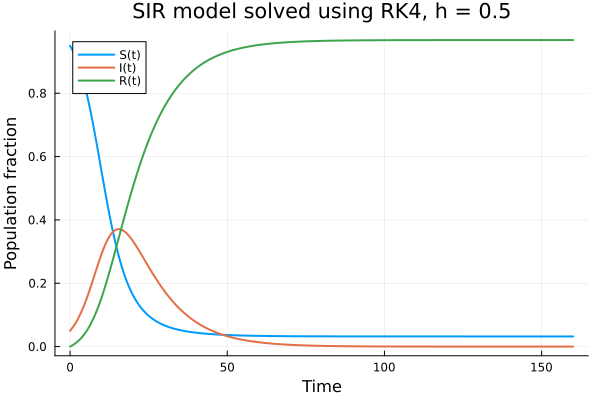

In [15]:
# Plot RK4 SIR solution using h = 0.5
h_rk4_plot = 0.5

t_rk4_plot, Y_rk4_plot =
    rk4_system(f_sir, t0_sir, y0_sir, T_sir, h_rk4_plot)

plot(t_rk4_plot, Y_rk4_plot[1, :], label="S(t)", linewidth=2)
plot!(t_rk4_plot, Y_rk4_plot[2, :], label="I(t)", linewidth=2)
plot!(t_rk4_plot, Y_rk4_plot[3, :], label="R(t)", linewidth=2)

xlabel!("Time")
ylabel!("Population fraction")
title!("SIR model solved using RK4, h = 0.5")

savefig("sir_rk4.png")
plot!()

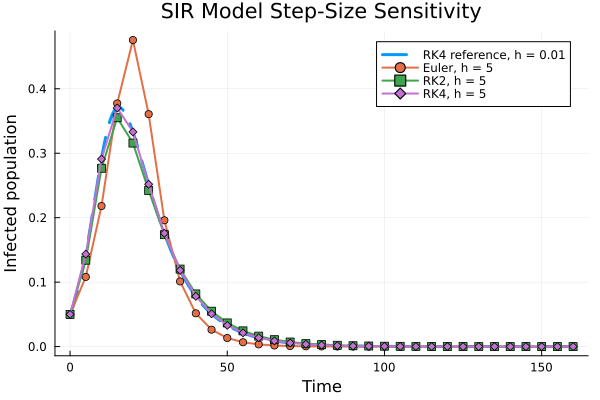

In [20]:
p = plot(
    t_ref, Y_ref[2, :],
    lw = 3,
    linestyle = :dash,
    label = "RK4 reference, h = 0.01",
    legend = :topright
)

plot!(p,
    t_e, Y_e[2, :],
    lw = 2,
    marker = :circle,
    label = "Euler, h = 5"
)

plot!(p,
    t_rk2, Y_rk2[2, :],
    lw = 2,
    marker = :square,
    label = "RK2, h = 5"
)

plot!(p,
    t_rk4, Y_rk4[2, :],
    lw = 2,
    marker = :diamond,
    label = "RK4, h = 5"
)

xlabel!("Time")
ylabel!("Infected population")
title!("SIR Model Step-Size Sensitivity")

savefig("sir_stepsize_comparison.png")

p

## Population Conservation Check

In [17]:
# Conservation check
total_population =
    Y_rk4[1, :] .+ Y_rk4[2, :] .+ Y_rk4[3, :]

max_conservation_error =
    maximum(abs.(total_population .- 1.0))

println(
    "Maximum conservation error: ",
    max_conservation_error
)

Maximum conservation error: 2.220446049250313e-16


## Appendix: Extended SIR Simulations

This appendix adds a small set of extra SIR simulations to strengthen the discussion. The existing `sir_rhs` and `rk4_system` functions are reused so that the notebook keeps a consistent structure throughout.


In [18]:
# =========================================================
# Appendix: extended SIR simulations
# =========================================================

function sir_summary(t, I)
    Imax, idx = findmax(I)
    tpeak = t[idx]
    return Imax, tpeak
end

# ---------------------------------------------------------
# 1. Effect of initial infection level
# ---------------------------------------------------------

initial_cases = [
    (0.99, 0.01, 0.00, "I₀ = 0.01"),
    (0.95, 0.05, 0.00, "I₀ = 0.05"),
    (0.90, 0.10, 0.00, "I₀ = 0.10")
]

p1 = plot(
    title = "Effect of Initial Infection Level on I(t)",
    xlabel = "Time",
    ylabel = "Infected fraction",
    linewidth = 2
)

println("\nExtended SIR results: varying initial infection level")
println("---------------------------------------------------")
println("Case        Imax        t_peak")
println("---------------------------------------------------")

for (S0_case, I0_case, R0_case, label) in initial_cases
    y0_case = [S0_case, I0_case, R0_case]
    f_case(t, y) = sir_rhs(t, y, beta_sir, gamma_sir)

    t_case, Y_case = rk4_system(f_case, t0_sir, y0_case, T_sir, h_sir)
    I_case = Y_case[2, :]

    plot!(p1, t_case, I_case, label = label)

    Imax, tpeak = sir_summary(t_case, I_case)
    println(rpad(label, 10), "  ",
        lpad(string(round(Imax, digits=4)), 8), "      ",
        lpad(string(round(tpeak, digits=2)), 5))
end

println("---------------------------------------------------")
savefig(p1, "sir_initial_conditions.png")
println("Saved plot to sir_initial_conditions.png")

# ---------------------------------------------------------
# 2. Effect of reproduction number
# ---------------------------------------------------------

parameter_cases = [
    (0.05, 0.10, "R₀ = 0.5"),
    (0.10, 0.10, "R₀ = 1.0"),
    (0.35, 0.10, "R₀ = 3.5")
]

p2 = plot(
    title = "Effect of Reproduction Number on I(t)",
    xlabel = "Time",
    ylabel = "Infected fraction",
    linewidth = 2
)

println("\nExtended SIR results: varying reproduction number")
println("---------------------------------------------------")
println("Case        Imax        t_peak")
println("---------------------------------------------------")

for (beta_case, gamma_case, label) in parameter_cases
    f_case(t, y) = sir_rhs(t, y, beta_case, gamma_case)

    t_case, Y_case = rk4_system(f_case, t0_sir, y0_sir, T_sir, h_sir)
    I_case = Y_case[2, :]

    plot!(p2, t_case, I_case, label = label)

    Imax, tpeak = sir_summary(t_case, I_case)
    println(rpad(label, 10), "  ",
        lpad(string(round(Imax, digits=4)), 8), "      ",
        lpad(string(round(tpeak, digits=2)), 5))
end

println("---------------------------------------------------")
savefig(p2, "sir_R0_comparison.png")
println("Saved plot to sir_R0_comparison.png")

# ---------------------------------------------------------
# 3. Population conservation check for appendix case
# ---------------------------------------------------------

f_check(t, y) = sir_rhs(t, y, beta_sir, gamma_sir)
t_check, Y_check = rk4_system(f_check, t0_sir, y0_sir, T_sir, h_sir)

total_population_check = Y_check[1, :] .+ Y_check[2, :] .+ Y_check[3, :]
max_conservation_error_check = maximum(abs.(total_population_check .- 1.0))

println("\nMaximum conservation error for appendix test: ", max_conservation_error_check)

# =========================================================
# Error versus function evaluations for the scalar test ODE
# =========================================================

evals_per_step = Dict(
    "Euler" => 1,
    "RK2"   => 2,
    "RK4"   => 4
)

fevals_common = [8, 16, 32, 64, 128, 256]

fevals_used = Dict{String, Vector{Float64}}()
errors_feval = Dict{String, Vector{Float64}}()

for (name, method) in scalar_methods
    xvals = Float64[]
    errvals = Float64[]

    s = evals_per_step[name]

    for fe in fevals_common
        if fe % s == 0
            N = fe ÷ s
            h_fe = (T - t0) / N

            t_fe, y_num_fe = method(f, t0, y0, T, h_fe)
            err_fe = max_error(t_fe, y_num_fe, y_exact)

            push!(xvals, Float64(fe))
            push!(errvals, err_fe)
        end
    end

    fevals_used[name] = xvals
    errors_feval[name] = errvals
end

p3 = plot(
    fevals_used["Euler"], errors_feval["Euler"],
    xscale = :log10,
    yscale = :log10,
    marker = :circle,
    linewidth = 2,
    label = "Euler"
)

plot!(
    p3,
    fevals_used["RK2"], errors_feval["RK2"],
    marker = :square,
    linewidth = 2,
    label = "RK2"
)

plot!(
    p3,
    fevals_used["RK4"], errors_feval["RK4"],
    marker = :diamond,
    linewidth = 2,
    label = "RK4"
)

xlabel!(p3, "Function evaluations")
ylabel!(p3, "Maximum global error")
title!(p3, "Error versus function evaluations")

savefig(p3, "error_vs_function_evaluations.png")
println("Saved plot to error_vs_function_evaluations.png")



Extended SIR results: varying initial infection level
---------------------------------------------------
Case        Imax        t_peak
---------------------------------------------------
I₀ = 0.01     0.3462       25.0
I₀ = 0.05     0.3702       15.0
I₀ = 0.10      0.372       10.0
---------------------------------------------------
Saved plot to sir_initial_conditions.png

Extended SIR results: varying reproduction number
---------------------------------------------------
Case        Imax        t_peak
---------------------------------------------------
R₀ = 0.5        0.05        0.0
R₀ = 1.0        0.05        0.0
R₀ = 3.5      0.3702       15.0
---------------------------------------------------
Saved plot to sir_R0_comparison.png

Maximum conservation error for appendix test: 2.220446049250313e-16
Saved plot to error_vs_function_evaluations.png
